In [7]:
# ============================================================
# Lab Work 1 — Task 1: Classification with Unmodified Attributes
# Author: Maria Malykhina (Group 1)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn modules required by the assignment:
# - train_test_split: 80/20 random split for each of the 10 runs
# - GridSearchCV:      hyperparameter search per run (assignment task 1c)
# - StandardScaler:    SVM requires scaling (lecture slide 68, Jaeger)
# - Pipeline:          chains the scaler and the SVM so that scaling is
#                      refit on the training data of every CV fold,
#                      preventing data leakage from test to train
# - SVC:               Support Vector Machine classifier required by the task
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Cosmetic settings for plots
plt.rcParams["figure.dpi"] = 100

# ---------- Load the dataset ----------
# The CSV file Wine_Test_01.csv lives in the repository root.
# The notebook itself lives in Task 1/, so we go one folder up with "../".
df = pd.read_csv("../Wine_Test_01.csv")

print("Dataset shape:", df.shape)               # rows, columns
print("\nColumns:", list(df.columns))
print("\nClass balance (Y = quality):")
print(df["quality"].value_counts())
print("\nFirst rows:")
df.head()

Dataset shape: (1143, 12)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Class balance (Y = quality):
quality
1    621
0    522
Name: count, dtype: int64

First rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


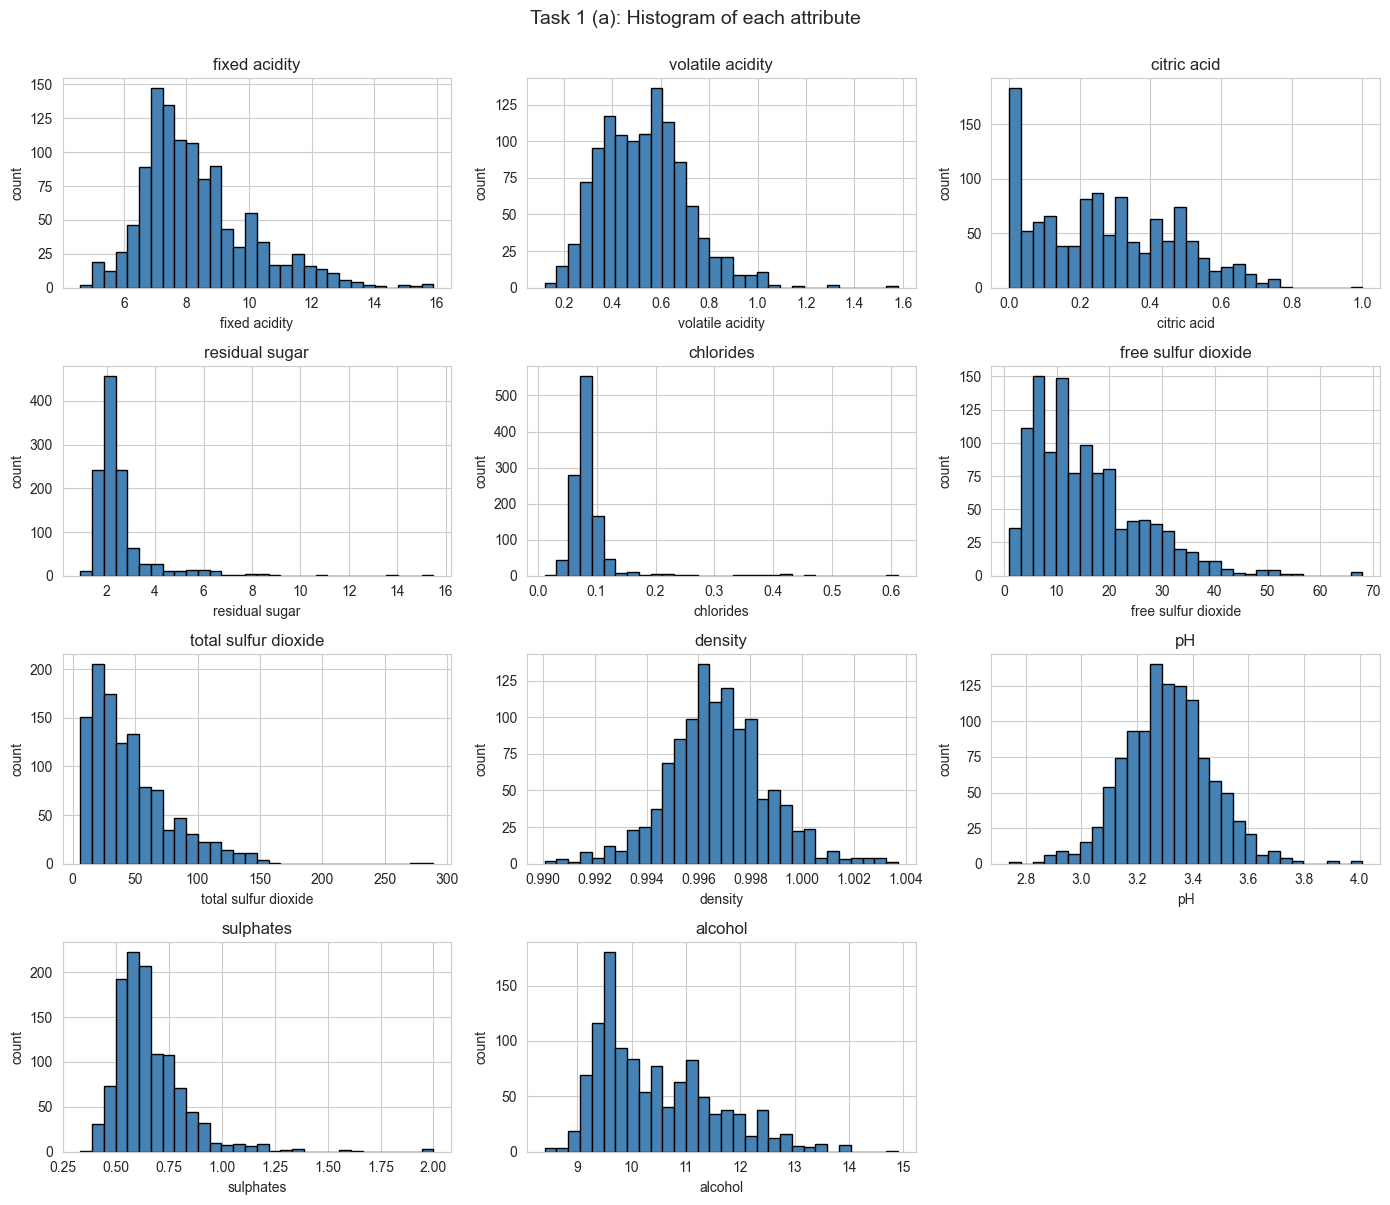

In [8]:
# ============================================================
# Task 1 (a): Histogram of each attribute (no class separation)
# ============================================================
# Goal: get a first overall view of the value ranges and shapes of the
# 11 attributes. This is the very first step of feature analysis as
# described in the Jaeger lecture, slide "(3) Feature analysis on row data":
# "Histogram analysis is a fundamental first step to observe the raw data."

# All columns except 'quality' are input attributes
attributes = [c for c in df.columns if c != "quality"]

# 11 attributes -> 4 rows x 3 columns grid (one cell will stay empty)
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()   # makes indexing easier

for i, attr in enumerate(attributes):
    axes[i].hist(df[attr], bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(attr)
    axes[i].set_xlabel(attr)
    axes[i].set_ylabel("count")

# Hide the unused 12th cell (we have 11 attributes, 12 slots in 4x3)
for j in range(len(attributes), len(axes)):
    axes[j].axis("off")

fig.suptitle("Task 1 (a): Histogram of each attribute", fontsize=14, y=1.00)
fig.tight_layout()
plt.show()

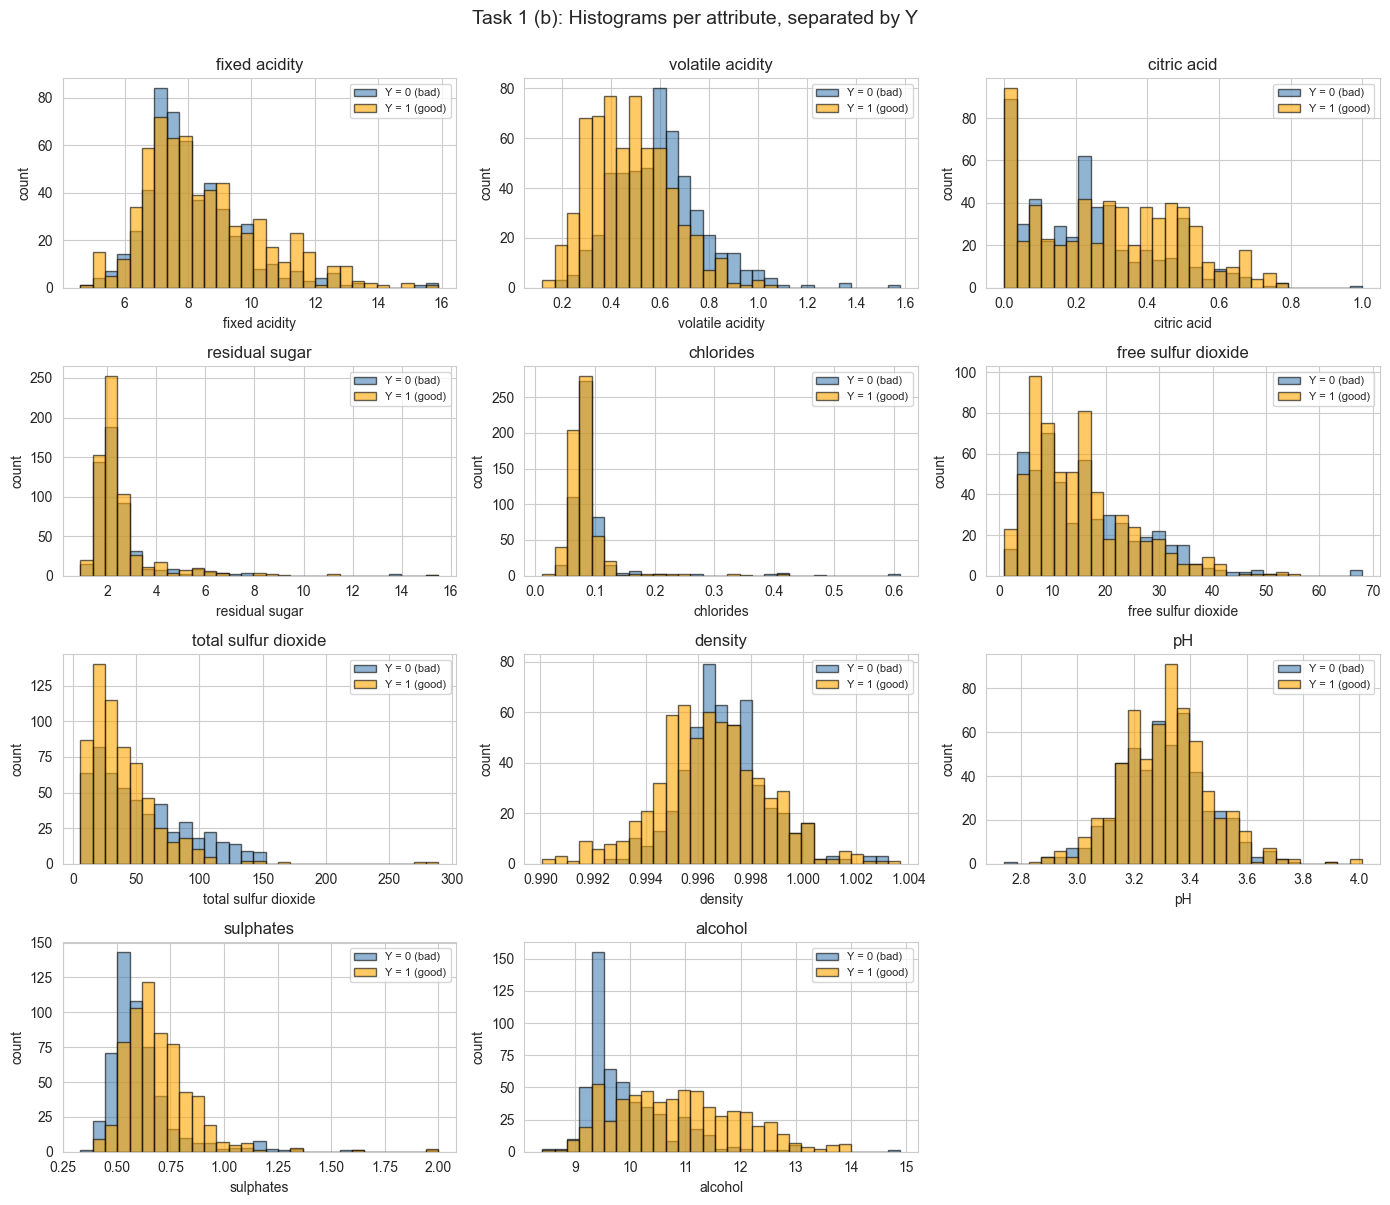

In [9]:
# =======================================================================================
# Task 1 (b): Show two histograms for each attribute with respect to Y. Please comment on
# the expected performance of the classifier. Please explain how you came to this
# conclusion.
# ========================================================================================
# Purpose: identify which attributes show a separation between the two
# classes (useful for the classifier) and which do not (the two
# distributions overlap almost completely -> attribute carries little
# discriminative information).

# Split the dataset into the two class subsets
df_bad  = df[df["quality"] == 0]    # quality <= 5
df_good = df[df["quality"] == 1]    # quality >  5

attributes = [c for c in df.columns if c != "quality"]

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, attr in enumerate(attributes):
    # Use a common bin edge set so that the two histograms are directly
    # comparable on the same x-scale.
    bins = np.linspace(df[attr].min(), df[attr].max(), 30)

    # Two overlapping histograms with transparency (alpha) so that we can
    # see where they overlap.
    axes[i].hist(df_bad[attr],  bins=bins, alpha=0.6,
                 color="steelblue", edgecolor="black", label="Y = 0 (bad)")
    axes[i].hist(df_good[attr], bins=bins, alpha=0.6,
                 color="orange",    edgecolor="black", label="Y = 1 (good)")
    axes[i].set_title(attr)
    axes[i].set_xlabel(attr)
    axes[i].set_ylabel("count")
    axes[i].legend(fontsize=8)

# Hide unused 12th subplot
for j in range(len(attributes), len(axes)):
    axes[j].axis("off")

fig.suptitle("Task 1 (b): Histograms per attribute, separated by Y",
             fontsize=14, y=1.00)
fig.tight_layout()
plt.show()

In [10]:
# ====================================================================
# Task 1 (c): 10 runs of modelling and test on the unmodified dataset
# ====================================================================
# In each run, split the dataset randomly into training and test (somewhat similar
# to k-fold cross-validation).
# - For each run a gridsearch with the same sets of hyperparameters, employing
# the Support Vector Machine (SVM), should be performed.
# - Display the best hyperparameters for each run.
# - With the best hyperparameter for each run, display the obtained Accuracy of
# the test data.
#
# Pipeline rationale (slide 68): SVM uses distances
# between samples, so attributes with large numeric ranges (e.g.
# total sulfur dioxide up to ~280) would dominate over attributes with
# small ranges (e.g. density around 0.99). StandardScaler removes
# this bias. Wrapping it together with the SVC in a Pipeline ensures
# that the scaler is refit on the training fold of every CV split,
# which prevents test-set information from leaking into training.

# ---------- Features (X) and target (y) ----------
X = df.drop(columns=["quality"])     # 11 input attributes
y = df["quality"]                    # binary target (0 / 1)

# ---------- Pipeline: scaler followed by SVM ----------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC()),
])

# ---------- Hyperparameter grid (same as agreed with team) ----------
# Prefix "svm__" tells GridSearch that the parameter belongs to the
# "svm" step of the Pipeline.
param_grid = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C":      [0.1, 1, 10, 100, 1000],
    "svm__gamma":  [1, 0.1, 0.01, 0.001, 0.0001],
}
# Total combinations: 2 * 5 * 5 = 50 per GridSearch call.

# ---------- 10 runs ----------
N_RUNS = 10
accuracies   = []   # test accuracy for every run
best_params  = []   # best hyperparameters for every run

print("Running 10 train/test runs with GridSearch (may take ~1 min)\n")

for run in range(N_RUNS):
    # Each run uses a different random_state so that train/test split
    # is different every time -> simulates "k-fold-like" repetition.
    # stratify=y keeps the class balance (621/522) in both train and
    # test, otherwise small splits could become unbalanced by chance.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=run, stratify=y
    )

    # GridSearchCV with 5-fold cross validation on the training set.
    # scoring="accuracy" because classes are roughly balanced
    # (lecture: "Accuracy is a good measure if all classes are balanced").
    # n_jobs=-1 uses all CPU cores in parallel.
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)

    # Evaluate the best estimator (with refit on the full train set,
    # which GridSearchCV does automatically by default) on the held-out
    # test set.
    test_acc = grid.score(X_test, y_test)

    accuracies.append(test_acc)
    best_params.append(grid.best_params_)

    print(f"Run {run + 1:2d}  accuracy = {test_acc:.4f}  "
          f"best params = {grid.best_params_}")

# ---------- Summary ----------
mean_acc = np.mean(accuracies)
std_acc  = np.std(accuracies)

print("\n" + "=" * 60)
print(f"Task 1c summary over {N_RUNS} runs")
print(f"  Mean accuracy: {mean_acc:.4f}")
print(f"  Std  accuracy: {std_acc:.4f}")
print("=" * 60)

Running 10 train/test runs with GridSearch (may take ~1 min)

Run  1  accuracy = 0.7860  best params = {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Run  2  accuracy = 0.7991  best params = {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Run  3  accuracy = 0.7642  best params = {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Run  4  accuracy = 0.7424  best params = {'svm__C': 1000, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Run  5  accuracy = 0.7642  best params = {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Run  6  accuracy = 0.7074  best params = {'svm__C': 1000, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
Run  7  accuracy = 0.7817  best params = {'svm__C': 1000, 'svm__gamma': 1, 'svm__kernel': 'linear'}
Run  8  accuracy = 0.7424  best params = {'svm__C': 1000, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Run  9  accuracy = 0.7686  best params = {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Run 10  accuracy = 0.7205  best params = {'svm__C': 